# Site Setup

Define your site once, interactively, and save a **single reusable JSON configuration** used by every historical notebook — both `air_temperature/a,b,c` and `rainfall/00a,00b,00c`.

This notebook replaces the two previous per-domain setup notebooks (`air_temperature/00_site_setup.ipynb` and `rainfall/00_local_site_setup.ipynb`); it now lives one level up, at `notebooks/historical/00_site_setup.ipynb`, so it is a sibling of both indicator folders.

**Prerequisites:** run this notebook before any of:
- `air_temperature/a_mean_temperature.ipynb`, `air_temperature/b_min_max_temperature.ipynb`, `air_temperature/c_hot_cold_days.ipynb`
- `rainfall/00a_Total_rainfall.ipynb`, `rainfall/00b_Consecutive_dry_days.ipynb`, `rainfall/00c_Heavy_rainfall.ipynb`

**Outputs:**
- `data/sites/<site>.json` — one shared site configuration (station ID, coordinates, reference period, requested variables).
- `data/air_temp/GHCN_<station_id>.pkl` — cleaned daily `TMIN` / `TMAX` time series (°C), if the station reports temperature.
- `data/rainfall/GHCN_<station_id>.pkl` — cleaned daily `PRCP` time series (mm), if the station reports precipitation.

**Workflow overview:**

1. Load the GHCN country catalog and inspect the map.
2. Enter your **country** and resolve the official GHCN country code.
3. List stations for that country and pick one **station ID**.
4. Auto-fill **site name**, **longitude** and **latitude** from the selected station.
5. Set **variables of interest** (`TMIN`, `TMAX`, `PRCP`), **reference period** and **completeness threshold**.
6. Save the shared site configuration JSON.
7. Download, filter and cache daily temperature (if `TMIN`/`TMAX` were requested and are available).
8. Download, filter and cache daily precipitation (if `PRCP` was requested and is available).
9. Inspect the downloaded series.


In [2]:
from pathlib import Path
import sys

import pandas as pd
import plotly.express as px
from IPython.display import display

sys.path.append("../../../functions")
from air_temp import save_site_config, site_config_filename, load_site_config, list_available_sites
from data_downloaders import GHCN, filter_by_time_completeness

## 1. Site fields (auto-filled after station choice)

`site_name`, `site_lon` and `site_lat` are initialised as `None` and populated automatically in Step 5 when a GHCN station is selected.


In [3]:
site_name = None
site_lon = None
site_lat = None

print("Site fields will be set automatically after selecting a station (Step 5).")

Site fields will be set automatically after selecting a station (Step 5).


## 2. Load the GHCN country catalog

This step downloads the official GHCN country code table (`Code`, `Country`) used by the map and by the country lookup step.


In [4]:
df_countries = GHCN.download_country_codes()
print(f"Loaded {len(df_countries)} country entries from GHCN.")
df_countries

Loaded 220 country entries from GHCN.


,Code,Country
0,AC,Antigua and Barbuda
1,AE,United Arab Emirates
2,AF,Afghanistan
3,AG,Algeria
4,AJ,Azerbaijan
...,...,...
215,WQ,Wake Island [United States]
216,WZ,Swaziland
217,ZA,Zambia
218,ZI,Zimbabwe


### Map of available countries

Each purple marker is one GHCN country, placed at the **median** latitude/longitude of all its stations. Hover for the country `Code`, full `Country` name and number of stations.

Use this map to identify the exact GHCN `Country` name, then set `country` in Step 3.


In [5]:
try:
    df_stations
except NameError:
    df_stations = GHCN.download_stations_info()

try:
    df_countries
except NameError:
    df_countries = GHCN.download_country_codes()

df_stations["Code"] = df_stations["ID"].str[:2]
country_centroids = (
    df_stations.groupby("Code")
    .agg(
        Latitude=("Latitude", "median"),
        Longitude=("Longitude", "median"),
        n_stations=("ID", "count"),
    )
    .reset_index()
)
country_map = country_centroids.merge(df_countries, on="Code", how="left")

center_lat = float(country_map["Latitude"].median())
center_lon = float(country_map["Longitude"].median())

fig = px.scatter_mapbox(
    country_map,
    lat="Latitude", lon="Longitude",
    hover_name="Country",
    hover_data={
        "Code": True,
        "n_stations": True,
        "Latitude": ":.2f",
        "Longitude": ":.2f",
    },
    color_discrete_sequence=["#8e44ad"],
    center={"lat": center_lat, "lon": center_lon},
    zoom=1.6,
    height=560,
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=0, r=0, t=90, b=0),
    title=dict(
        text=f"GHCN countries (median station location) - {len(country_centroids)} countries",
        x=0.5, xanchor="center",
        y=0.985, yanchor="top",
        pad=dict(t=10),
        font=dict(size=13),
    ),
    modebar=dict(orientation="v", bgcolor="rgba(255,255,255,0.6)"),
)
fig.show(config={"scrollZoom": False})

## 3. Choose country and resolve GHCN code

Set `country` to the exact GHCN country name (use the map above to identify the correct spelling). The notebook resolves the two-letter GHCN country code used to filter stations in the next step.

If no exact match is found, a list of similar country names is displayed — copy the correct name back into `country` and re-run.


In [6]:
country = "Palau"  # e.g. "Palau"

assert country.strip(), "Set `country` with a GHCN country name before running this cell."

exact = GHCN.get_country_code(country)

if len(exact) == 1:
    country_code = exact["Code"].iloc[0]
    country_name = exact["Country"].iloc[0]
    print(f"Exact match: {country_name!r} -> code {country_code!r}")
else:
    suggestions = df_countries[
        df_countries["Country"].str.contains(country, case=False, na=False)
    ]
    if len(suggestions) == 0:
        print(
            f"No country matches {country!r}. Showing the full list so you can "
            "pick one; copy it back into the `country` variable above and re-run."
        )
        display(df_countries)
    else:
        print(
            f"{len(suggestions)} possible matches for {country!r}. "
            "Copy the exact name into `country` above and re-run this step."
        )
        display(suggestions)
    country_code = None
    country_name = None

Exact match: 'Palau' -> code 'PS'


## 4. List stations for the selected country

Downloads the full GHCN-Daily station list and element inventory, filters to the selected country code, and merges each station's period of record for `TMIN`, `TMAX` and `PRCP`.

The interactive map and table below help you choose a station with a long, reliable record.


In [7]:
assert country_code is not None, "Resolve the country code in Step 3 before running this cell."

df_stations = GHCN.download_stations_info()
df_inventory = GHCN.download_station_inventory()
df_country_stations = df_stations[df_stations["ID"].str.startswith(country_code)].copy()

nearest = (
    df_country_stations
    .sort_values(["Name", "ID"])
    .reset_index(drop=True)
)

record_years = GHCN.summarize_record_years(
    df_inventory, nearest["ID"], elements=("TMIN", "TMAX", "PRCP")
)
nearest = nearest.merge(record_years, on="ID", how="left")

print(f"{len(nearest)} GHCN stations registered under country code {country_code!r}.")

13 GHCN stations registered under country code 'PS'.


### Map of country stations

Each blue marker is one GHCN station. Hover for the station ID, name, elevation and record span. Pick a station ID for Step 5.


In [8]:
map_df = nearest.copy()
center_lat = float(map_df["Latitude"].median())
center_lon = float(map_df["Longitude"].median())

lat_span = float(map_df["Latitude"].max() - map_df["Latitude"].min())
lon_span = float(map_df["Longitude"].max() - map_df["Longitude"].min())
span = max(lat_span, lon_span)
if span < 0.5:
    zoom = 10
elif span < 1.5:
    zoom = 8
elif span < 5:
    zoom = 6
else:
    zoom = 4

fig = px.scatter_mapbox(
    map_df,
    lat="Latitude", lon="Longitude",
    color_discrete_sequence=["#3498db"],
    hover_name="Name",
    hover_data={
        "ID": True,
        "Elevation": True,
        "record_years": True,
        "elements": True,
        "Latitude": ":.3f",
        "Longitude": ":.3f",
    },
    center={"lat": center_lat, "lon": center_lon},
    zoom=zoom,
    height=500,
)
fig.update_layout(
    mapbox_style="open-street-map",
    height=560,
    margin=dict(l=0, r=0, t=90, b=0),
    title=dict(
        text=f"GHCN stations in {country_name} ({len(map_df)} stations)",
        x=0.5, xanchor="center",
        y=0.985, yanchor="top",
        pad=dict(t=10),
        font=dict(size=13),
    ),
    showlegend=False,
    modebar=dict(orientation="v", bgcolor="rgba(255,255,255,0.6)"),
)
fig.show(config={"scrollZoom": False})

In [9]:
station_table_cols = [
    "ID", "Name", "Latitude", "Longitude", "Elevation",
    "record_start", "record_end", "record_years", "elements",
]
display(nearest[station_table_cols].head(30))

,ID,Name,Latitude,Longitude,Elevation,record_start,record_end,record_years,elements
0,PSC00914015,PW AIMELIK BABELTHUAP,7.4500,134.5167,60.0,1953,1955,1953-1955,"PRCP, TMAX, TMIN"
1,PSC00914030,PW ANGUAR,6.9167,134.1500,6.1,1955,1977,1955-1977,"PRCP, TMAX, TMIN"
2,PSW00040309,PW KOROR GSN 91408,7.3367,134.4769,27.4,1951,2026,1951-2026,"PRCP, TMAX, TMIN"
3,PSW00040307,PW KOROR ISLAND NF,7.3333,134.4833,30.2,1947,1951,1947-1951,"PRCP, TMAX, TMIN"
4,PSC00914465,PW MALAKAL RSCH,7.3333,134.4500,75.9,1955,1955,1955-1955,PRCP
5,PSC00914478,PW MARICULTURE CTR,7.3333,134.4500,3.0,1990,2004,1990-2004,"PRCP, TMAX, TMIN"
6,PSC00914519,PW NEKKEN FORESTRY,7.4500,134.5000,31.1,1983,2026,1983-2026,"PRCP, TMAX, TMIN"
7,PSC00914580,PW NGASANG BABELTHUAP,7.6333,134.6500,3.0,1955,1979,1955-1979,"PRCP, TMAX, TMIN"
8,PSC00914712,PW PELELIU,7.0333,134.2667,3.0,1991,2026,1991-2026,"PRCP, TMAX, TMIN"
9,PSW00040305,PW PELELIU ISLAND PALAU ISLANDS,7.0000,134.2500,5.2,1945,1947,1945-1947,"PRCP, TMAX, TMIN"


## 5. Pick a station and auto-fill site metadata

Set `ghcn_station_id` to one of the IDs from the table in Step 4. The notebook auto-fills `site_lon`, `site_lat`, `ghcn_station_name` and `site_name` from the GHCN metadata.

`site_name` — the key used everywhere downstream (config filename, cached pickles' site tag, figures/tables directories) — is built as `<country>_<ghcn_station_id>` (e.g. `palau_PSW00040309`), so it stays unique per station even when several stations share the same country.


In [11]:
ghcn_station_id = "PSW00040309"#"PSW00040309"  # choose an ID from the table in Step 4

assert ghcn_station_id in nearest["ID"].values, (
    f"Station ID {ghcn_station_id!r} not found among stations for country code {country_code!r}."
)
station_row = nearest.loc[nearest["ID"] == ghcn_station_id].iloc[[0]]

ghcn_station_name = station_row["Name"].iloc[0]
site_lon = float(station_row["Longitude"].iloc[0])
site_lat = float(station_row["Latitude"].iloc[0])

country_slug = "".join(ch.lower() if ch.isalnum() else "_" for ch in country_name).strip("_")
country_slug = "_".join(part for part in country_slug.split("_") if part)
site_name = f"{country_slug}_{ghcn_station_id}"

print(f"Selected station: {ghcn_station_id} - {ghcn_station_name}")
print(f"Auto-filled site coordinates: ({site_lat:+.3f}, {site_lon:+.3f})")
print(f"Auto-filled site name: {site_name}")

Selected station: PSW00040309 - PW KOROR GSN 91408
Auto-filled site coordinates: (+7.337, +134.477)
Auto-filled site name: palau_PSW00040309


## 6. Variables and reference period

| Parameter | Default | Description |
|---|---|---|
| `vars_interest` | `["TMIN", "TMAX", "PRCP"]` | GHCN variables to download. Any that aren't available at the station are skipped with a warning in Steps 7–8. |
| `reference_period_start` / `_end` | `"1961"` / `"1990"` | WMO climatology baseline for anomalies |
| `completeness_threshold` | `0.75` | Minimum data completeness to keep a month/year |


In [12]:
vars_interest = ["TMIN", "TMAX", "PRCP"]
reference_period_start = "1961"
reference_period_end = "1990"
completeness_threshold = 0.75

print(f"Variables of interest: {vars_interest}")
print(f"Reference period: {reference_period_start}-{reference_period_end}")
print(f"Completeness threshold: {completeness_threshold:.0%}")

Variables of interest: ['TMIN', 'TMAX', 'PRCP']
Reference period: 1961-1990
Completeness threshold: 75%


## 7. Save the site configuration

Writes `data/sites/<site>.json` with all site metadata. Analysis notebooks in **both** `air_temperature/` and `rainfall/` load this same file via `load_site_config()` — never hardcode site values in the indicator notebooks.


In [ ]:
site_config = {
    "site_name": site_name,
    "site_lon": float(site_lon),
    "site_lat": float(site_lat),
    "country": country_name,
    "ghcn_station_id": ghcn_station_id,
    "ghcn_station_name": ghcn_station_name,
    "vars_interest": list(vars_interest),
    "reference_period_start": str(reference_period_start),
    "reference_period_end": str(reference_period_end),
    "completeness_threshold": float(completeness_threshold),
}

config_out = Path("../../../data/sites") / site_config_filename(site_name)

save_site_config(site_config, config_out)
print(f"Saved site config: {config_out.resolve()}")
site_config

## 8. Temperature (`TMIN` / `TMAX`)

Downloads daily `TMIN` / `TMAX` from GHCN-Daily and caches the result at `data/air_temp/GHCN_<station_id>.pkl`. When both variables are available, derived columns `TMEAN = (TMAX + TMIN) / 2` and `diff = TMAX − TMIN` are added.

Skipped automatically if `TMIN`/`TMAX` are not in `vars_interest` or not available at the station. Set `force_redownload = True` below to refresh the cache from NOAA servers.


In [ ]:
force_redownload = True

GHCND_dir = "https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/"
temp_dir = Path("../../../data/air_temp")
temp_dir.mkdir(parents=True, exist_ok=True)
temp_pickle_path = temp_dir / f"GHCN_{ghcn_station_id}.pkl"

temp_vars = [v for v in ("TMIN", "TMAX") if v in vars_interest]
df_target = df_country_stations.loc[df_country_stations["ID"] == ghcn_station_id]

if not temp_vars:
    print("TMIN/TMAX not in vars_interest - skipping temperature download.")
    temp_data = None
elif temp_pickle_path.exists() and not force_redownload:
    temp_data = pd.read_pickle(temp_pickle_path)
    print(f"Loaded cached temperature data: {temp_pickle_path}")
    print("Set force_redownload = True above to refresh.")
else:
    print(f"Downloading {', '.join(temp_vars)} for station {ghcn_station_id}...")

    frames = []
    for var in temp_vars:
        result, _ = GHCN.extract_dict_data_var(GHCND_dir, var, df_target)
        if not result:
            print(f"  WARNING: variable {var!r} not available for {ghcn_station_id}.")
            continue
        frames.append(result[0]["data"])

    if not frames:
        print(f"None of {temp_vars} are available for station {ghcn_station_id}.")
        temp_data = None
    else:
        temp_data = pd.concat(frames, axis=1).dropna()
        if {"TMIN", "TMAX"}.issubset(temp_data.columns):
            temp_data["diff"] = temp_data["TMAX"] - temp_data["TMIN"]
            temp_data["TMEAN"] = (temp_data["TMAX"] + temp_data["TMIN"]) / 2
        temp_data.to_pickle(temp_pickle_path)
        print(f"Saved {len(temp_data)} rows to {temp_pickle_path}")

if temp_data is not None:
    print(f"Date range: {temp_data.index.min().date()} to {temp_data.index.max().date()}")

### Time-completeness filter (temperature)

Applies `filter_by_time_completeness()` to remove months and years with insufficient observations. The filtered DataFrame overwrites the cached pickle.


In [15]:
if temp_data is not None:
    temp_data, removed_months_temp, removed_years_temp = filter_by_time_completeness(
        temp_data,
        month_threshold=completeness_threshold,
        year_threshold=completeness_threshold,
    )
    print(f"[Temperature] Removed {removed_months_temp.shape[0]} months due to insufficient data: {removed_months_temp.index.tolist()}")
    print(f"[Temperature] Removed {removed_years_temp.shape[0]} years due to insufficient data: {removed_years_temp.index.tolist()}")
    temp_data.to_pickle(temp_pickle_path)
    print(f"Updated cached pickle: {temp_pickle_path}")
else:
    print("No temperature data to filter.")

[Temperature] Removed 13 months due to insufficient data: [(2018, 8), (2019, 1), (2020, 3), (2022, 7), (2022, 10), (2022, 11), (2022, 12), (2023, 1), (2023, 6), (2023, 8), (2023, 12), (2024, 2), (2026, 7)]
[Temperature] Removed 3 years due to insufficient data: [2019, 2022, 2023]
Updated cached pickle: ../../data/air_temp/GHCN_PSW00040309.pkl


## 9. Precipitation (`PRCP`)

Downloads daily `PRCP` from GHCN-Daily and caches the result at `data/rainfall/GHCN_<station_id>.pkl`.

Skipped automatically if `PRCP` is not in `vars_interest` or not available at the station.


In [ ]:
rain_dir = Path("../../../data/rainfall")
rain_dir.mkdir(parents=True, exist_ok=True)
rain_pickle_path = rain_dir / f"GHCN_{ghcn_station_id}.pkl"

if "PRCP" not in vars_interest:
    print("PRCP not in vars_interest - skipping precipitation download.")
    rain_data = None
elif rain_pickle_path.exists() and not force_redownload:
    rain_data = pd.read_pickle(rain_pickle_path)
    print(f"Loaded cached precipitation data: {rain_pickle_path}")
    print("Set force_redownload = True above to refresh.")
else:
    print(f"Downloading PRCP for station {ghcn_station_id}...")
    result, _ = GHCN.extract_dict_data_var(GHCND_dir, "PRCP", df_target)
    if not result:
        print(f"  WARNING: variable 'PRCP' not available for {ghcn_station_id}.")
        rain_data = None
    else:
        rain_data = result[0]["data"].dropna()
        rain_data.to_pickle(rain_pickle_path)
        print(f"Saved {len(rain_data)} rows to {rain_pickle_path}")

if rain_data is not None:
    print(f"Date range: {rain_data.index.min().date()} to {rain_data.index.max().date()}")

### Time-completeness filter (precipitation)

Same filter as above, applied independently to the `PRCP` series.


In [17]:
if rain_data is not None:
    rain_data, removed_months_rain, removed_years_rain = filter_by_time_completeness(
        rain_data,
        month_threshold=completeness_threshold,
        year_threshold=completeness_threshold,
    )
    print(f"[Precipitation] Removed {removed_months_rain.shape[0]} months due to insufficient data: {removed_months_rain.index.tolist()}")
    print(f"[Precipitation] Removed {removed_years_rain.shape[0]} years due to insufficient data: {removed_years_rain.index.tolist()}")
    rain_data.to_pickle(rain_pickle_path)
    print(f"Updated cached pickle: {rain_pickle_path}")
else:
    print("No precipitation data to filter.")

[Precipitation] Removed 9 months due to insufficient data: [(2018, 8), (2019, 1), (2022, 7), (2022, 11), (2022, 12), (2023, 1), (2023, 8), (2024, 2), (2026, 7)]
[Precipitation] Removed 1 years due to insufficient data: [2019]
Updated cached pickle: ../../data/rainfall/GHCN_PSW00040309.pkl


## 10. Quick look at the downloaded data

Sanity-check plots (one per domain, if data is available). These are quality-control figures, not published indicators.

**Next steps:** open `air_temperature/a_mean_temperature.ipynb` and/or `rainfall/00a_Total_rainfall.ipynb`.


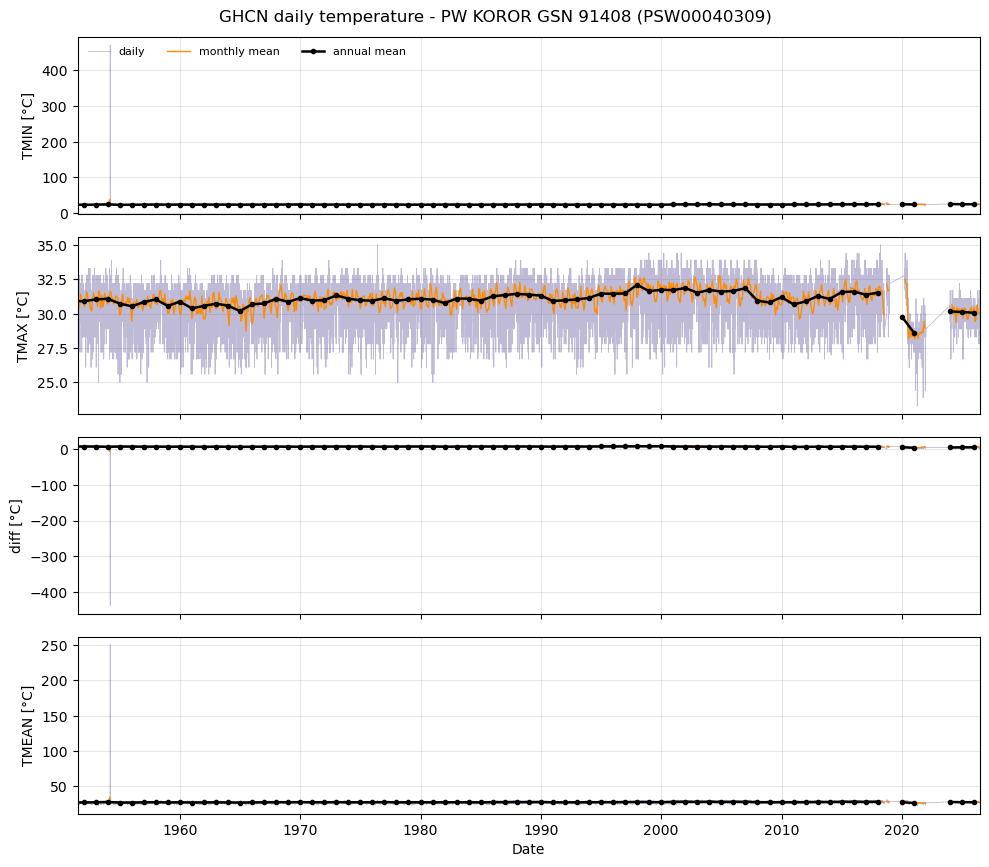

In [18]:
import matplotlib.pyplot as plt

if temp_data is not None:
    cols = list(temp_data.columns)
    monthly = temp_data[cols].resample("MS").mean()
    annual = temp_data[cols].resample("YS").mean()

    fig, axes = plt.subplots(len(cols), 1, figsize=(10, 2.2 * len(cols)), sharex=True)
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.plot(temp_data.index, temp_data[col], lw=0.6, color="darkslateblue", alpha=0.35, label="daily")
        ax.plot(monthly.index, monthly[col], lw=1.0, color="darkorange", label="monthly mean")
        ax.plot(annual.index, annual[col], lw=1.8, color="black", marker="o", ms=3, label="annual mean")
        ax.set_xlim(temp_data.index.min(), temp_data.index.max())
        ax.set_ylabel(f"{col} [°C]" if col != "diff" else "diff [°C]")
        ax.grid(alpha=0.3)

    axes[0].legend(loc="upper left", ncol=3, fontsize=8, frameon=False)
    axes[-1].set_xlabel("Date")
    fig.suptitle(f"GHCN daily temperature - {ghcn_station_name} ({ghcn_station_id})")
    fig.tight_layout()
    plt.show()
else:
    print("No temperature data to plot.")

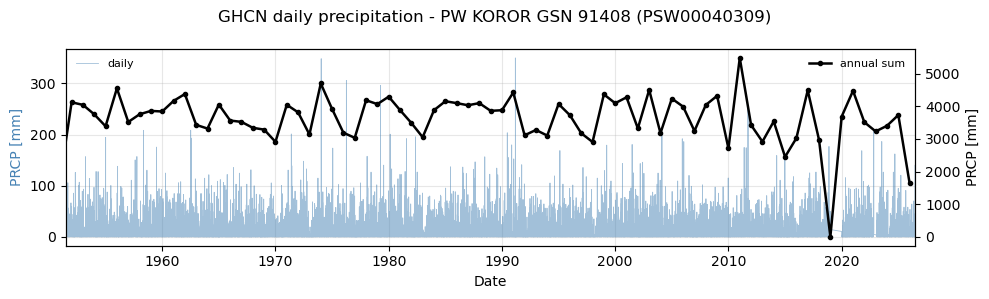

In [19]:
if rain_data is not None:
    monthly = rain_data["PRCP"].resample("MS").sum()
    annual = rain_data["PRCP"].resample("YS").sum()

    fig, ax = plt.subplots(figsize=(10, 3), sharex=True)
    ax2 = ax.twinx()
    ax.plot(rain_data.index, rain_data["PRCP"], lw=0.6, color="steelblue", alpha=0.5, label="daily")
    ax2.plot(annual.index, annual, lw=1.8, color="black", marker="o", ms=3, label="annual sum")
    ax.set_xlim(rain_data.index.min(), rain_data.index.max())
    ax.set_ylabel("PRCP [mm]", color = 'steelblue')
    ax2.set_ylabel("PRCP [mm]", color = 'black')
    ax.legend(loc="upper left", ncol=3, fontsize=8, frameon=False)
    ax.set_xlabel("Date")
    ax2.legend(loc="upper right", ncol=3, fontsize=8, frameon=False)
    ax.grid(alpha=0.3)
    fig.suptitle(f"GHCN daily precipitation - {ghcn_station_name} ({ghcn_station_id})")
    fig.tight_layout()
    plt.show()
else:
    print("No precipitation data to plot.")